<a href="https://colab.research.google.com/github/Salimam00/pinn-thermoelasticity-rods/blob/main/PINN_Deep_Ritz_Thermoelasticity_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import json, time
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn

# ============================================================
# Deep Ritz PINN for a 1D thermoelastic rod
# Reproducible Colab/GitHub version
# ============================================================

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
torch.set_default_dtype(torch.float64)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ---------------- Physical parameters ----------------
L = 1.0                  # m
A0 = 1.0e-3              # m^2
BETA = 3.0
E = 200.0e9              # Pa
ALPHA = 1.2e-5           # 1/K
DELTA_T_MAX = 100.0      # K
P = 1.0e4                # N

# ---------------- Neural network ----------------
HIDDEN_LAYERS = 4
NEURONS = 50

# ---------------- Optimization ----------------
N_QUADRATURE = 200
ADAM_EPOCHS = 5000
ADAM_LR = 1.0e-3
LBFGS_MAX_ITER = 500

# Independent validation grid
N_TEST = 400

OUTPUT_DIR = Path("results")
OUTPUT_DIR.mkdir(exist_ok=True)

# Characteristic displacement for numerical conditioning.
# It does NOT change the physical solution; it only scales the NN output.
U_SCALE = P * L / (E * A0) + ALPHA * DELTA_T_MAX * L


# ============================================================
# Geometry and thermal field
# ============================================================

def area(x):
    return A0 / (1.0 + BETA * (x / L) ** 2)


def temperature_change(x):
    return DELTA_T_MAX * (x / L)


def area_np(x):
    return A0 / (1.0 + BETA * (x / L) ** 2)


def temperature_change_np(x):
    return DELTA_T_MAX * (x / L)


# ============================================================
# Analytical solution
# ============================================================

def analytical_displacement(x):
    x = np.asarray(x, dtype=float)
    return (
        P / (E * A0)
        * (x + BETA * x**3 / (3.0 * L**2))
        + ALPHA * DELTA_T_MAX * x**2 / (2.0 * L)
    )


def analytical_stress(x):
    x = np.asarray(x, dtype=float)
    return P / area_np(x)


# ============================================================
# Deep Ritz network
# ============================================================

class DeepRitzThermoelasticity(nn.Module):
    """
    Dimensionless coordinate and output scaling improve conditioning.

    u_theta(x) = U_SCALE * (x/L) * N_theta(x/L)

    Therefore u_theta(0)=0 exactly.
    """

    def __init__(self, hidden_layers=4, neurons_per_layer=50):
        super().__init__()

        layers = [
            nn.Linear(1, neurons_per_layer),
            nn.Tanh()
        ]

        for _ in range(hidden_layers - 1):
            layers.extend([
                nn.Linear(neurons_per_layer, neurons_per_layer),
                nn.Tanh()
            ])

        layers.append(nn.Linear(neurons_per_layer, 1))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        xi = x / L
        return U_SCALE * xi * self.net(xi)


# ============================================================
# Gauss-Legendre quadrature
# ============================================================

def gauss_legendre_points(n):
    nodes, weights = np.polynomial.legendre.leggauss(n)

    x = 0.5 * L * (nodes + 1.0)
    w = 0.5 * L * weights

    x = torch.tensor(x, device=DEVICE).view(-1, 1)
    w = torch.tensor(w, device=DEVICE).view(-1, 1)

    return x, w


# ============================================================
# Dimensionless Deep Ritz energy
# ============================================================

def compute_energy_loss(model, x_quad, weights):
    """
    Physical potential energy:

    Pi[u] = integral[
        1/2 E A (u')^2 - E A alpha DeltaT u'
    ] dx - P u(L)

    The objective is divided by a positive constant E*A0*U_SCALE^2/L
    for numerical conditioning. This does not change the minimizer.
    """

    x = x_quad.detach().clone().requires_grad_(True)
    u = model(x)

    du_dx = torch.autograd.grad(
        u,
        x,
        grad_outputs=torch.ones_like(u),
        create_graph=True
    )[0]

    A = area(x)
    dT = temperature_change(x)

    density = (
        0.5 * E * A * du_dx**2
        - E * A * ALPHA * dT * du_dx
    )

    internal_energy = torch.sum(weights * density)

    xL = torch.tensor([[L]], device=DEVICE)
    uL = model(xL)
    external_work = P * uL.squeeze()

    physical_energy = internal_energy - external_work

    scale = E * A0 * U_SCALE**2 / L
    return physical_energy / scale


# ============================================================
# Training
# ============================================================

def train():
    model = DeepRitzThermoelasticity(
        HIDDEN_LAYERS, NEURONS
    ).to(DEVICE)

    xq, wq = gauss_legendre_points(N_QUADRATURE)

    history = []
    phases = []

    t0 = time.perf_counter()

    # ---- Stage 1: Adam ----
    adam = torch.optim.Adam(model.parameters(), lr=ADAM_LR)

    for epoch in range(ADAM_EPOCHS):
        adam.zero_grad()
        loss = compute_energy_loss(model, xq, wq)
        loss.backward()
        adam.step()

        value = float(loss.detach().cpu())
        history.append(value)
        phases.append("Adam")

        if (epoch + 1) % 1000 == 0:
            print(
                f"Adam {epoch+1:5d}/{ADAM_EPOCHS} "
                f"| dimensionless energy = {value:.8e}"
            )

    # ---- Stage 2: L-BFGS ----
    lbfgs = torch.optim.LBFGS(
        model.parameters(),
        max_iter=LBFGS_MAX_ITER,
        tolerance_grad=1e-10,
        tolerance_change=1e-14,
        history_size=100,
        line_search_fn="strong_wolfe"
    )

    calls = 0

    def closure():
        nonlocal calls
        lbfgs.zero_grad()
        loss = compute_energy_loss(model, xq, wq)
        loss.backward()
        history.append(float(loss.detach().cpu()))
        phases.append("L-BFGS")
        calls += 1
        return loss

    lbfgs.step(closure)

    elapsed = time.perf_counter() - t0

    return model, history, phases, elapsed, calls


# ============================================================
# Prediction and validation
# ============================================================

def predict_displacement(model, x):
    xt = torch.tensor(
        x, device=DEVICE
    ).view(-1, 1)

    with torch.no_grad():
        u = model(xt)

    return u.cpu().numpy().ravel()


def predict_stress(model, x):
    xt = torch.tensor(
        x, device=DEVICE
    ).view(-1, 1).requires_grad_(True)

    u = model(xt)

    du_dx = torch.autograd.grad(
        u,
        xt,
        grad_outputs=torch.ones_like(u),
        create_graph=False
    )[0]

    sigma = E * (
        du_dx - ALPHA * temperature_change(xt)
    )

    return sigma.detach().cpu().numpy().ravel()


def metrics(pred, exact):
    e = pred - exact
    return {
        "MAE_m": float(np.mean(np.abs(e))),
        "RMSE_m": float(np.sqrt(np.mean(e**2))),
        "Relative_L2": float(
            np.linalg.norm(e) / np.linalg.norm(exact)
        ),
        "Max_absolute_error_m": float(np.max(np.abs(e))),
    }


def boundary_checks(model):
    x0 = torch.tensor([[0.0]], device=DEVICE)
    xL = torch.tensor([[L]], device=DEVICE).requires_grad_(True)

    u0 = model(x0)
    uL = model(xL)

    duL = torch.autograd.grad(
        uL, xL,
        grad_outputs=torch.ones_like(uL)
    )[0]

    sigmaL = E * (
        duL - ALPHA * temperature_change(xL)
    )

    forceL = area(xL) * sigmaL

    u0 = float(u0.detach().cpu())
    forceL = float(forceL.detach().cpu())

    return {
        "u0_m": u0,
        "target_force_N": P,
        "predicted_force_N": forceL,
        "relative_force_error": abs(forceL - P) / P
    }


# ============================================================
# Save results
# ============================================================

def save_results(model, history, phases, elapsed, lbfgs_calls):

    x = np.linspace(0, L, N_TEST)

    u_exact = analytical_displacement(x)
    u_pred = predict_displacement(model, x)

    sigma_exact = analytical_stress(x)
    sigma_pred = predict_stress(model, x)

    m = metrics(u_pred, u_exact)
    bc = boundary_checks(model)

    # Prediction table
    df = pd.DataFrame({
        "x_m": x,
        "area_m2": area_np(x),
        "temperature_change_K": temperature_change_np(x),
        "u_analytical_m": u_exact,
        "u_deep_ritz_m": u_pred,
        "absolute_error_m": np.abs(u_pred - u_exact),
        "stress_analytical_Pa": sigma_exact,
        "stress_deep_ritz_Pa": sigma_pred
    })

    df.to_csv(
        OUTPUT_DIR / "prediction_data.csv",
        index=False
    )

    all_metrics = {
        **m,
        **bc,
        "training_time_s": elapsed,
        "quadrature_points": N_QUADRATURE,
        "adam_epochs": ADAM_EPOCHS,
        "adam_learning_rate": ADAM_LR,
        "lbfgs_max_iter": LBFGS_MAX_ITER,
        "lbfgs_closure_calls": lbfgs_calls,
        "hidden_layers": HIDDEN_LAYERS,
        "neurons_per_layer": NEURONS,
        "U_SCALE_m": U_SCALE
    }

    pd.DataFrame([all_metrics]).to_csv(
        OUTPUT_DIR / "metrics.csv",
        index=False
    )

    with open(OUTPUT_DIR / "metrics.json", "w") as f:
        json.dump(all_metrics, f, indent=2)

    config = {
        "L_m": L,
        "A0_m2": A0,
        "beta": BETA,
        "E_Pa": E,
        "alpha_1_per_K": ALPHA,
        "Delta_T_max_K": DELTA_T_MAX,
        "P_N": P,
        "hidden_layers": HIDDEN_LAYERS,
        "neurons_per_layer": NEURONS,
        "quadrature_points": N_QUADRATURE,
        "adam_epochs": ADAM_EPOCHS,
        "adam_learning_rate": ADAM_LR,
        "lbfgs_max_iter": LBFGS_MAX_ITER,
        "validation_points": N_TEST,
        "random_seed": SEED
    }

    with open(OUTPUT_DIR / "configuration.json", "w") as f:
        json.dump(config, f, indent=2)

    torch.save(
        model.state_dict(),
        OUTPUT_DIR / "deep_ritz_model.pt"
    )

    # ---- Figures ----
    plt.figure(figsize=(7.5, 5), dpi=300)
    plt.plot(x, area_np(x) * 1e6, linewidth=2.2)
    plt.xlabel("Coordinate x (m)")
    plt.ylabel("Cross-sectional area A(x) (mm$^2$)")
    plt.title("Variable cross-sectional area")
    plt.grid(True, linestyle="--", alpha=0.6)
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "01_area_profile.png", bbox_inches="tight")
    plt.close()

    plt.figure(figsize=(7.5, 5), dpi=300)
    plt.plot(x, temperature_change_np(x), linewidth=2.2)
    plt.xlabel("Coordinate x (m)")
    plt.ylabel("Temperature increase ΔT(x) (K)")
    plt.title("Prescribed temperature field")
    plt.grid(True, linestyle="--", alpha=0.6)
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "02_temperature_profile.png", bbox_inches="tight")
    plt.close()

    plt.figure(figsize=(8, 5), dpi=300)
    plt.plot(x, u_exact * 1e3, linewidth=2.5, label="Analytical solution")
    plt.plot(x, u_pred * 1e3, "--", linewidth=2.0, label="Deep Ritz PINN")
    plt.xlabel("Coordinate x (m)")
    plt.ylabel("Displacement u(x) (mm)")
    plt.title("Thermoelastic displacement")
    plt.grid(True, linestyle="--", alpha=0.6)
    plt.legend()
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "03_displacement_comparison.png", bbox_inches="tight")
    plt.close()

    plt.figure(figsize=(8, 5), dpi=300)
    plt.plot(x, np.abs(u_pred - u_exact) * 1e6, linewidth=2.0)
    plt.xlabel("Coordinate x (m)")
    plt.ylabel("Absolute error (μm)")
    plt.title("Displacement error")
    plt.grid(True, linestyle="--", alpha=0.6)
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "04_displacement_error.png", bbox_inches="tight")
    plt.close()

    plt.figure(figsize=(8, 5), dpi=300)
    plt.plot(x, sigma_exact / 1e6, linewidth=2.5, label="Analytical solution")
    plt.plot(x, sigma_pred / 1e6, "--", linewidth=2.0, label="Deep Ritz PINN")
    plt.xlabel("Coordinate x (m)")
    plt.ylabel("Axial stress σ(x) (MPa)")
    plt.title("Thermoelastic stress")
    plt.grid(True, linestyle="--", alpha=0.6)
    plt.legend()
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "05_stress_comparison.png", bbox_inches="tight")
    plt.close()

    adam_count = sum(p == "Adam" for p in phases)
    it = np.arange(1, len(history) + 1)

    plt.figure(figsize=(8, 5), dpi=300)
    plt.semilogy(
        it[:adam_count],
        np.maximum(np.abs(history[:adam_count]), 1e-16),
        linewidth=1.5,
        label="Adam"
    )
    if adam_count < len(history):
        plt.semilogy(
            it[adam_count:],
            np.maximum(np.abs(history[adam_count:]), 1e-16),
            linewidth=1.5,
            label="L-BFGS"
        )
        plt.axvline(
            adam_count,
            linestyle=":",
            linewidth=1.3,
            label="Optimizer switch"
        )
    plt.xlabel("Optimization iteration")
    plt.ylabel("Absolute dimensionless energy")
    plt.title("Deep Ritz energy convergence")
    plt.grid(True, linestyle="--", alpha=0.6)
    plt.legend()
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "06_energy_convergence.png", bbox_inches="tight")
    plt.close()

    print("\n========== FINAL RESULTS ==========")
    for k, v in all_metrics.items():
        if isinstance(v, (int, float)):
            print(f"{k:28s}: {v:.8e}" if isinstance(v, float) else f"{k:28s}: {v}")

    return all_metrics


def main():
    print("==============================================")
    print("Deep Ritz PINN Thermoelasticity")
    print("Reproducible validation run")
    print("==============================================")
    print("Device:", DEVICE)

    model, history, phases, elapsed, calls = train()

    save_results(
        model,
        history,
        phases,
        elapsed,
        calls
    )

    print("\nResults written to:", OUTPUT_DIR.resolve())


if __name__ == "__main__":
    main()


Deep Ritz PINN Thermoelasticity
Reproducible validation run
Device: cpu
Adam  1000/5000 | dimensionless energy = -8.15291861e-02
Adam  2000/5000 | dimensionless energy = -8.15332733e-02
Adam  3000/5000 | dimensionless energy = -8.15333383e-02
Adam  4000/5000 | dimensionless energy = -8.15334116e-02
Adam  5000/5000 | dimensionless energy = -8.15334173e-02

========== FINAL RESULTS ==========
MAE_m                       : 3.22542899e-08
RMSE_m                      : 4.01859198e-08
Relative_L2                 : 1.27362080e-04
Max_absolute_error_m        : 9.17908638e-08
u0_m                        : 0.00000000e+00
target_force_N              : 1.00000000e+04
predicted_force_N           : 9.81503082e+03
relative_force_error        : 1.84969182e-02
training_time_s             : 4.18524979e+01
quadrature_points           : 200
adam_epochs                 : 5000
adam_learning_rate          : 1.00000000e-03
lbfgs_max_iter              : 500
lbfgs_closure_calls         : 626
hidden_layers      

In [ ]:
# ============================================================
# QUADRATURE SENSITIVITY ANALYSIS
# N = 50, 100, 200, 400
# ============================================================

import time
import numpy as np
import pandas as pd
import torch

print("=" * 80)
print("QUADRATURE SENSITIVITY ANALYSIS")
print("=" * 80)

# Values requested for the sensitivity study
quadrature_values = [50, 100, 200, 400]

# Independent validation set
N_VALIDATION = 400

results = []

# Remember the original value
original_N_QUADRATURE = N_QUADRATURE

for N in quadrature_values:

    print("\n" + "=" * 80)
    print(f"RUNNING DEEP RITZ WITH N_QUADRATURE = {N}")
    print("=" * 80)

    # Change only the quadrature resolution
    N_QUADRATURE = N

    # Use the same random seed for a fair comparison
    np.random.seed(SEED)
    torch.manual_seed(SEED)

    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(SEED)

    # --------------------------------------------------------
    # Train the model using your ORIGINAL train() function
    # --------------------------------------------------------

    model_N, history_N, phases_N, elapsed_N, calls_N = train()

    # --------------------------------------------------------
    # Independent validation on 400 points
    # --------------------------------------------------------

    x_val = np.linspace(0, L, N_VALIDATION)

    u_exact = analytical_displacement(x_val)
    u_pred = predict_displacement(model_N, x_val)

    # Convert to numpy arrays if necessary
    u_exact = np.asarray(u_exact).reshape(-1)
    u_pred = np.asarray(u_pred).reshape(-1)

    # --------------------------------------------------------
    # Relative L2 displacement error
    # --------------------------------------------------------

    relative_l2_error = (
        np.linalg.norm(u_pred - u_exact)
        / np.linalg.norm(u_exact)
    ) * 100.0

    # Maximum absolute displacement error
    maximum_absolute_error = np.max(
        np.abs(u_pred - u_exact)
    )

    results.append({
        "Quadrature points": N,
        "Relative L2 displacement error (%)": relative_l2_error,
        "Maximum absolute displacement error (m)": maximum_absolute_error,
        "Training time (s)": elapsed_N,
        "L-BFGS closure calls": calls_N
    })

    print("\nRESULT")
    print("-" * 50)
    print(
        f"Relative L2 displacement error: "
        f"{relative_l2_error:.6f}%"
    )
    print(
        f"Maximum absolute displacement error: "
        f"{maximum_absolute_error:.6e} m"
    )
    print(
        f"Total training time: "
        f"{elapsed_N:.4f} s"
    )
    print(
        f"L-BFGS closure calls: "
        f"{calls_N}"
    )


# ------------------------------------------------------------
# Restore the original quadrature value
# ------------------------------------------------------------

N_QUADRATURE = original_N_QUADRATURE


# ------------------------------------------------------------
# Final sensitivity table
# ------------------------------------------------------------

sensitivity_df = pd.DataFrame(results)

print("\n")
print("=" * 80)
print("FINAL QUADRATURE SENSITIVITY TABLE")
print("=" * 80)

display(sensitivity_df)


# ------------------------------------------------------------
# Save results
# ------------------------------------------------------------

sensitivity_df.to_csv(
    "quadrature_sensitivity_results.csv",
    index=False
)

print("\nSaved file:")
print("quadrature_sensitivity_results.csv")

print("\nOriginal N_QUADRATURE restored to:", N_QUADRATURE)

QUADRATURE SENSITIVITY ANALYSIS

RUNNING DEEP RITZ WITH N_QUADRATURE = 50
Adam  1000/5000 | dimensionless energy = -8.15291861e-02
Adam  2000/5000 | dimensionless energy = -8.15332733e-02
Adam  3000/5000 | dimensionless energy = -8.15333404e-02
Adam  4000/5000 | dimensionless energy = -8.15334140e-02
Adam  5000/5000 | dimensionless energy = -8.15334202e-02

RESULT
--------------------------------------------------
Relative L2 displacement error: 0.012352%
Maximum absolute displacement error: 8.859716e-08 m
Total training time: 22.5517 s
L-BFGS closure calls: 626

RUNNING DEEP RITZ WITH N_QUADRATURE = 100
Adam  1000/5000 | dimensionless energy = -8.15291861e-02
Adam  2000/5000 | dimensionless energy = -8.15332733e-02
Adam  3000/5000 | dimensionless energy = -8.15333397e-02
Adam  4000/5000 | dimensionless energy = -8.15334144e-02
Adam  5000/5000 | dimensionless energy = -8.15334202e-02

RESULT
--------------------------------------------------
Relative L2 displacement error: 0.012355%
Ma

,Quadrature points,Relative L2 displacement error (%),Maximum absolute displacement error (m),Training time (s),L-BFGS closure calls
0,50,0.012352,8.859716e-08,22.551663,626
1,100,0.012355,8.858545e-08,24.047155,626
2,200,0.012736,9.179086e-08,30.852003,626
3,400,0.012695,9.131200e-08,41.381790,626



Saved file:
quadrature_sensitivity_results.csv

Original N_QUADRATURE restored to: 200


In [ ]:
# ============================================================
# GRAPHS FOR THE DEEP RITZ THERMOELASTICITY RESULTS
# ============================================================

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Папка с результатами
RESULTS_DIR = "/content/results"

print("Results directory:", RESULTS_DIR)

# ------------------------------------------------------------
# Проверяем, какие файлы создал основной код
# ------------------------------------------------------------

print("\nFiles in results folder:")

for file in sorted(os.listdir(RESULTS_DIR)):
    print(" -", file)

# ------------------------------------------------------------
# Загружаем prediction_data.csv
# ------------------------------------------------------------

prediction_file = os.path.join(
    RESULTS_DIR,
    "prediction_data.csv"
)

df = pd.read_csv(prediction_file)

print("\nPrediction data loaded successfully.")
print("Columns:")
print(df.columns.tolist())

print("\nFirst five rows:")
display(df.head())

Results directory: /content/results

Files in results folder:
 - 01_area_profile.png
 - 02_temperature_profile.png
 - 03_displacement_comparison.png
 - 04_displacement_error.png
 - 05_stress_comparison.png
 - 06_energy_convergence.png
 - configuration.json
 - deep_ritz_model.pt
 - metrics.csv
 - metrics.json
 - prediction_data.csv

Prediction data loaded successfully.
Columns:
['x_m', 'area_m2', 'temperature_change_K', 'u_analytical_m', 'u_deep_ritz_m', 'absolute_error_m', 'stress_analytical_Pa', 'stress_deep_ritz_Pa']

First five rows:


,x_m,area_m2,temperature_change_K,u_analytical_m,u_deep_ritz_m,absolute_error_m,stress_analytical_Pa,stress_deep_ritz_Pa
0,0.000000,0.001,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+07,1.014148e+07
1,0.002506,0.001,0.250627,1.290829e-07,1.307989e-07,1.716001e-09,1.000019e+07,1.013262e+07
2,0.005013,0.001,0.501253,2.657081e-07,2.690280e-07,3.319899e-09,1.000075e+07,1.012434e+07
3,0.007519,0.001,0.751880,4.098805e-07,4.146949e-07,4.814410e-09,1.000170e+07,1.011667e+07
4,0.010025,0.001,1.002506,5.616046e-07,5.678069e-07,6.202241e-09,1.000302e+07,1.010958e+07


In [ ]:
df.to_csv("prediction_data.csv", index=False)

In [ ]:
print("CSV создан!")
print("Строк:", len(df))
print("Столбцов:", len(df.columns))

CSV создан!
Строк: 400
Столбцов: 8


In [ ]:
import os

os.makedirs("results", exist_ok=True)

df.to_csv("results/prediction_data.csv", index=False)

print("CSV сохранён в папке results")
print("Строк:", len(df))
print("Столбцов:", len(df.columns))

CSV сохранён в папке results
Строк: 400
Столбцов: 8


In [ ]:
from google.colab import files

files.download("results/prediction_data.csv")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

url = "https://raw.githubusercontent.com/Salimam00/pinn-thermoelasticity-rods/main/prediction_data.csv"

df = pd.read_csv(url)

print("Размер таблицы:", df.shape)
display(df.head())

Размер таблицы: (400, 8)


,x_m,area_m2,temperature_change_K,u_analytical_m,u_deep_ritz_m,absolute_error_m,stress_analytical_Pa,stress_deep_ritz_Pa
0,0.000000,0.001,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+07,1.014148e+07
1,0.002506,0.001,0.250627,1.290829e-07,1.307989e-07,1.716001e-09,1.000019e+07,1.013262e+07
2,0.005013,0.001,0.501253,2.657081e-07,2.690280e-07,3.319899e-09,1.000075e+07,1.012434e+07
3,0.007519,0.001,0.751880,4.098805e-07,4.146949e-07,4.814410e-09,1.000170e+07,1.011667e+07
4,0.010025,0.001,1.002506,5.616046e-07,5.678069e-07,6.202241e-09,1.000302e+07,1.010958e+07


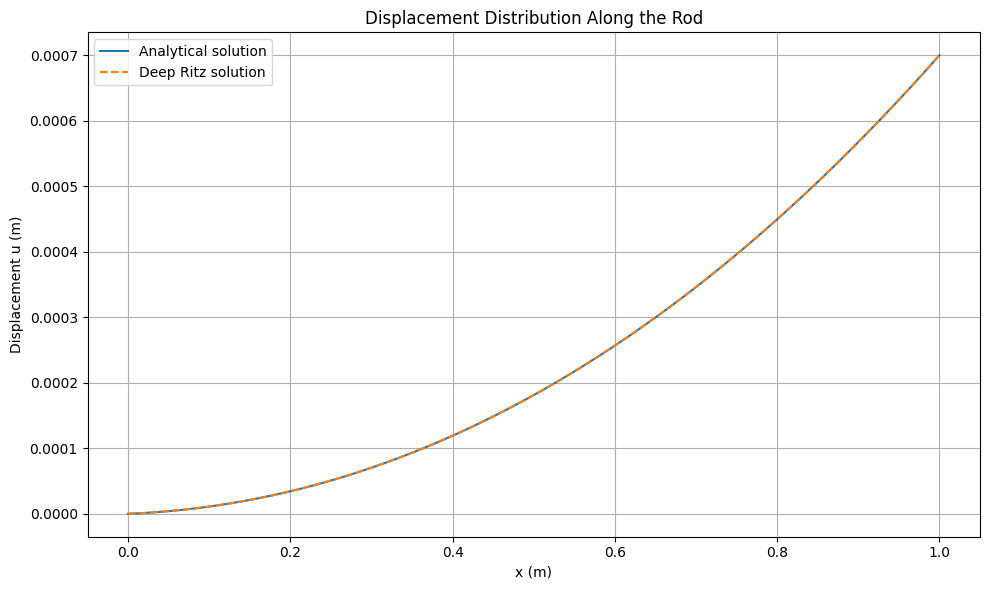

In [ ]:
plt.figure(figsize=(10, 6))

plt.plot(
    df["x_m"],
    df["u_analytical_m"],
    label="Analytical solution"
)

plt.plot(
    df["x_m"],
    df["u_deep_ritz_m"],
    "--",
    label="Deep Ritz solution"
)

plt.xlabel("x (m)")
plt.ylabel("Displacement u (m)")
plt.title("Displacement Distribution Along the Rod")
plt.legend()
plt.grid(True)
plt.tight_layout()

plt.show()

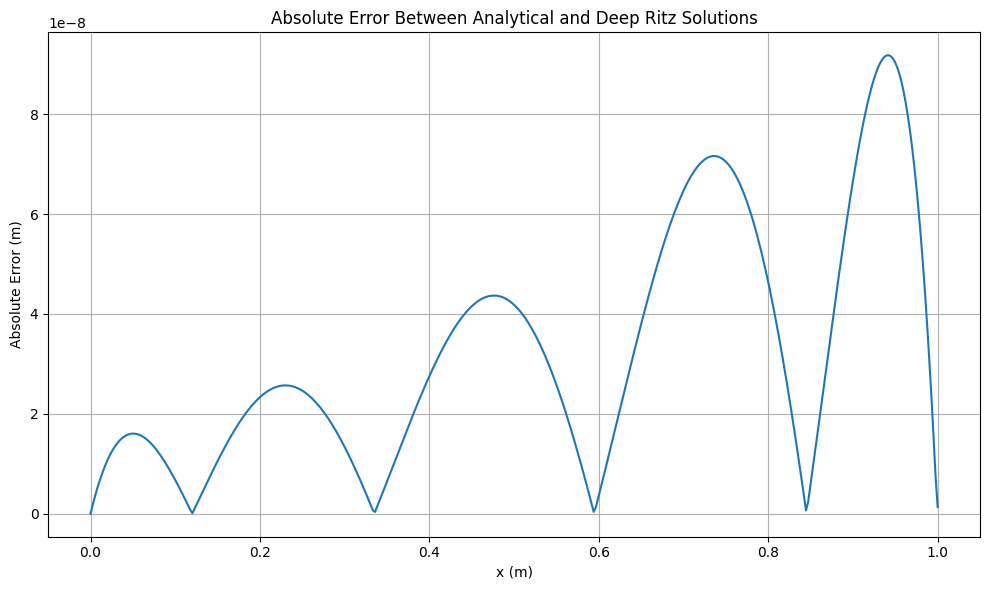

In [ ]:
plt.figure(figsize=(10, 6))

plt.plot(
    df["x_m"],
    df["absolute_error_m"]
)

plt.xlabel("x (m)")
plt.ylabel("Absolute Error (m)")
plt.title("Absolute Error Between Analytical and Deep Ritz Solutions")
plt.grid(True)
plt.tight_layout()

plt.show()

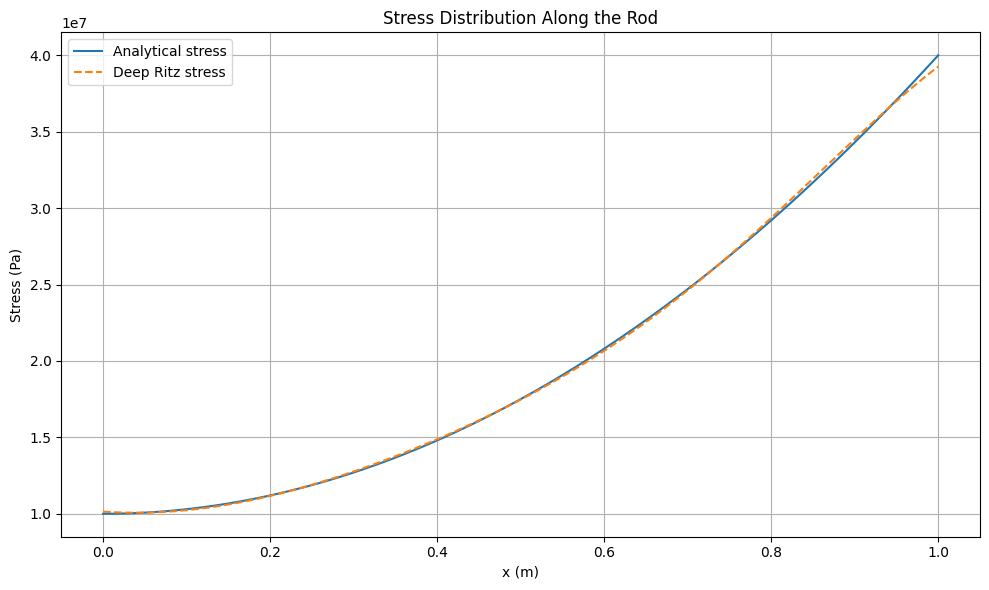

In [ ]:
plt.figure(figsize=(10, 6))

plt.plot(
    df["x_m"],
    df["stress_analytical_Pa"],
    label="Analytical stress"
)

plt.plot(
    df["x_m"],
    df["stress_deep_ritz_Pa"],
    "--",
    label="Deep Ritz stress"
)

plt.xlabel("x (m)")
plt.ylabel("Stress (Pa)")
plt.title("Stress Distribution Along the Rod")
plt.legend()
plt.grid(True)
plt.tight_layout()

plt.show()


In [ ]:
print("Количество точек:", len(df))

print("\nМаксимальная абсолютная ошибка:")
print(df["absolute_error_m"].max())

print("\nСредняя абсолютная ошибка:")
print(df["absolute_error_m"].mean())

print("\nМаксимальное аналитическое перемещение:")
print(df["u_analytical_m"].abs().max())

print("\nМаксимальное Deep Ritz перемещение:")
print(df["u_deep_ritz_m"].abs().max())

print("\nМаксимальное аналитическое напряжение:")
print(df["stress_analytical_Pa"].abs().max())

print("\nМаксимальное Deep Ritz напряжение:")
print(df["stress_deep_ritz_Pa"].abs().max())

Количество точек: 400

Максимальная абсолютная ошибка:
9.179086376046292e-08

Средняя абсолютная ошибка:
3.225428988381902e-08

Максимальное аналитическое перемещение:
0.0007

Максимальное Deep Ritz перемещение:
0.0006999986433341

Максимальное аналитическое напряжение:
40000000.0

Максимальное Deep Ritz напряжение:
39260123.27343893


In [ ]:
print("=== DEMONSTRATION RESULTS ===")

print(f"Количество точек: {len(df)}")

print(
    f"Максимальная абсолютная ошибка: "
    f"{df['absolute_error_m'].max():.6e} m"
)

print(
    f"Средняя абсолютная ошибка: "
    f"{df['absolute_error_m'].mean():.6e} m"
)

print(
    f"Максимальное аналитическое перемещение: "
    f"{df['u_analytical_m'].abs().max():.6e} m"
)

print(
    f"Максимальное Deep Ritz перемещение: "
    f"{df['u_deep_ritz_m'].abs().max():.6e} m"
)

print(
    f"Максимальное аналитическое напряжение: "
    f"{df['stress_analytical_Pa'].abs().max():.6e} Pa"
)

print(
    f"Максимальное Deep Ritz напряжение: "
    f"{df['stress_deep_ritz_Pa'].abs().max():.6e} Pa"
)

=== DEMONSTRATION RESULTS ===
Количество точек: 1000
Максимальная абсолютная ошибка: 1.925590e-07 m
Средняя абсолютная ошибка: 1.081170e-07 m
Максимальное аналитическое перемещение: 4.000000e-04 m
Максимальное Deep Ritz перемещение: 4.000000e-04 m
Максимальное аналитическое напряжение: 8.000000e+07 Pa
Максимальное Deep Ritz напряжение: 8.000000e+07 Pa
